
# Aplicación de CRISP-DM para predecir el rendimiento de combustible con XGBoost

## Regresión aplicada al dataset Auto MPG

### Curso: Minería de Datos
- **Gomez Coaquira Jeymi Johan**


En este trabajo se aplica la metodología **CRISP-DM** desde el entendimiento del negocio hasta la evaluación.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda valor: f"{valor:.4f}")
print("Las librerías se importaron correctamente.")


Las librerías se importaron correctamente.



# 1. Entendimiento del negocio

## 1.1 Contexto

El rendimiento de combustible influye en el costo de uso de un vehículo, en el consumo de energía y en la decisión de compra.

La variable **MPG** indica cuántas millas puede recorrer un automóvil utilizando un galón de combustible. Un valor mayor de MPG representa un mejor rendimiento.

## 1.2 Problema del negocio

No siempre es posible estimar el rendimiento observando una sola característica. El número de cilindros, el peso, la potencia, el desplazamiento, la aceleración, el año y el origen pueden influir conjuntamente.

## 1.3 Pregunta del análisis

> ¿Cuál será el valor de MPG de un vehículo a partir de sus características técnicas?

## 1.4 Objetivo general

Desarrollar un modelo de regresión con **XGBoost** para predecir el rendimiento de combustible de los vehículos.

## 1.5 Objetivos específicos

- Comprender el contenido y la calidad del dataset.
- Identificar valores faltantes, duplicados y posibles valores atípicos.
- Preparar las variables para el entrenamiento.
- Construir un modelo `XGBRegressor`.
- Evaluar el resultado con MAE, MSE, RMSE, MAPE y $R^2$.
- Comprobar la estabilidad mediante validación cruzada.

## 1.6 Criterios de éxito

El modelo será aceptable si:

- El MAE de prueba es menor a 3 MPG.
- El RMSE de prueba es menor a 4 MPG.
- El $R^2$ de prueba es igual o superior a 0.80.
- No existe una diferencia excesiva entre entrenamiento y prueba.



# 2. Entendimiento de los datos

## 2.1 Carga del dataset

El archivo `auto-mpg.data` debe encontrarse en la misma carpeta que el cuaderno.


In [2]:

# Guardamos en una variable el nombre del archivo que contiene el dataset.
ruta_datos = "auto-mpg.data"

# Creamos una lista con los nombres de las columnas, porque el archivo original no tiene encabezados.
columnas = [
    "mpg",           # Rendimiento expresado en millas por galón.
    "cylinders",     # Número de cilindros del motor.
    "displacement",  # Desplazamiento o cilindrada del motor.
    "horsepower",    # Potencia del motor.
    "weight",        # Peso del vehículo.
    "acceleration",  # Tiempo de aceleración.
    "model_year",    # Año del modelo.
    "origin",        # Región de origen del vehículo.
    "car_name"       # Nombre del automóvil.
]

# Leemos el archivo de texto y guardamos los datos en un DataFrame.
df = pd.read_csv(
    ruta_datos,      # Indicamos el archivo que será leído.
    sep=r"\s+",      # Indicamos que las columnas están separadas por uno o más espacios.
    names=columnas,  # Asignamos los nombres definidos anteriormente.
    na_values="?",   # Convertimos el símbolo ? en un valor faltante.
    quotechar='"'    # Conservamos correctamente los nombres de los automóviles.
)

# Mostramos los primeros cinco registros para verificar la carga.
display(df.head())

# Mostramos la cantidad de filas del dataset.
print("Cantidad de filas:", df.shape[0])

# Mostramos la cantidad de columnas del dataset.
print("Cantidad de columnas:", df.shape[1])


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0000,8,307.0000,130.0000,3504.0000,12.0000,70,1,chevrolet chevelle malibu
1,15.0000,8,350.0000,165.0000,3693.0000,11.5000,70,1,buick skylark 320
2,18.0000,8,318.0000,150.0000,3436.0000,11.0000,70,1,plymouth satellite
3,16.0000,8,304.0000,150.0000,3433.0000,12.0000,70,1,amc rebel sst
4,17.0000,8,302.0000,140.0000,3449.0000,10.5000,70,1,ford torino


Cantidad de filas: 398
Cantidad de columnas: 9



## 2.2 Diccionario de variables

| Variable | Descripción | Tipo |
|---|---|---|
| `mpg` | Millas recorridas por galón | Numérica continua |
| `cylinders` | Número de cilindros | Discreta |
| `displacement` | Desplazamiento del motor | Continua |
| `horsepower` | Potencia del motor | Continua |
| `weight` | Peso del automóvil | Continua |
| `acceleration` | Tiempo de aceleración | Continua |
| `model_year` | Año del modelo | Discreta |
| `origin` | Región de origen | Categórica |
| `car_name` | Nombre del automóvil | Texto |


## 2.3 Revisión inicial de los datos

In [3]:

# Mostramos el tipo de dato almacenado en cada columna.
display(df.dtypes.to_frame("tipo_de_dato"))

# Contamos los valores faltantes de cada columna.
valores_faltantes = df.isna().sum()

# Mostramos los valores faltantes en forma de tabla.
display(valores_faltantes.to_frame("cantidad_faltante"))

# Contamos los registros completamente duplicados.
cantidad_duplicados = df.duplicated().sum()

# Mostramos la cantidad de registros duplicados.
print("Registros duplicados:", cantidad_duplicados)

# Calculamos las estadísticas descriptivas de las variables numéricas.
resumen_estadistico = df.describe().T

# Mostramos el resumen estadístico.
display(resumen_estadistico)


,tipo_de_dato
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,float64
acceleration,float64
model_year,int64
origin,int64
car_name,str


,cantidad_faltante
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


Registros duplicados: 0


,count,mean,std,min,25%,50%,75%,max
mpg,398.0000,23.5146,7.8160,9.0000,17.5000,23.0000,29.0000,46.6000
cylinders,398.0000,5.4548,1.7010,3.0000,4.0000,4.0000,8.0000,8.0000
displacement,398.0000,193.4259,104.2698,68.0000,104.2500,148.5000,262.0000,455.0000
horsepower,392.0000,104.4694,38.4912,46.0000,75.0000,93.5000,126.0000,230.0000
weight,398.0000,2970.4246,846.8418,1613.0000,2223.7500,2803.5000,3608.0000,5140.0000
acceleration,398.0000,15.5681,2.7577,8.0000,13.8250,15.5000,17.1750,24.8000
model_year,398.0000,76.0101,3.6976,70.0000,73.0000,76.0000,79.0000,82.0000
origin,398.0000,1.5729,0.8021,1.0000,1.0000,1.0000,2.0000,3.0000



### Hallazgos iniciales

- El dataset tiene 398 registros.
- La variable `horsepower` contiene valores faltantes.
- `mpg` es numérica continua y será la variable objetivo.
- `car_name` contiene muchos nombres diferentes y funciona principalmente como identificador.


## 2.4 Distribución de MPG

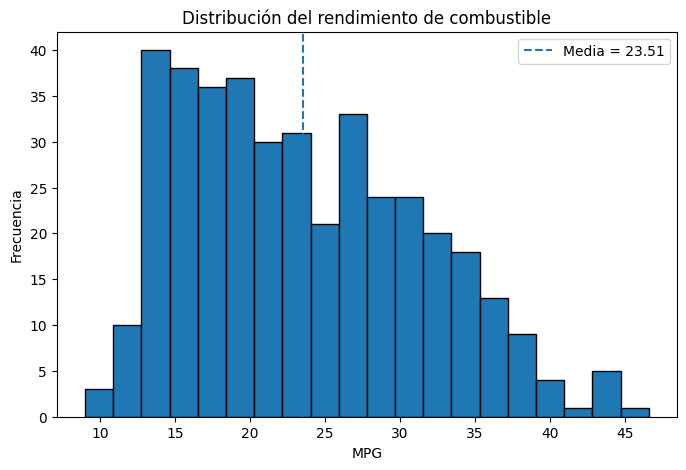

In [4]:

# Creamos una figura con un tamaño adecuado.
plt.figure(figsize=(8, 5))

# Dibujamos el histograma de la variable MPG.
plt.hist(df["mpg"], bins=20, edgecolor="black")

# Dibujamos una línea vertical para representar la media.
plt.axvline(
    df["mpg"].mean(),
    linestyle="--",
    label=f"Media = {df['mpg'].mean():.2f}"
)

# Agregamos el título del gráfico.
plt.title("Distribución del rendimiento de combustible")

# Colocamos el nombre del eje horizontal.
plt.xlabel("MPG")

# Colocamos el nombre del eje vertical.
plt.ylabel("Frecuencia")

# Mostramos la leyenda.
plt.legend()

# Mostramos el gráfico.
plt.show()


## 2.5 Relación entre peso y MPG

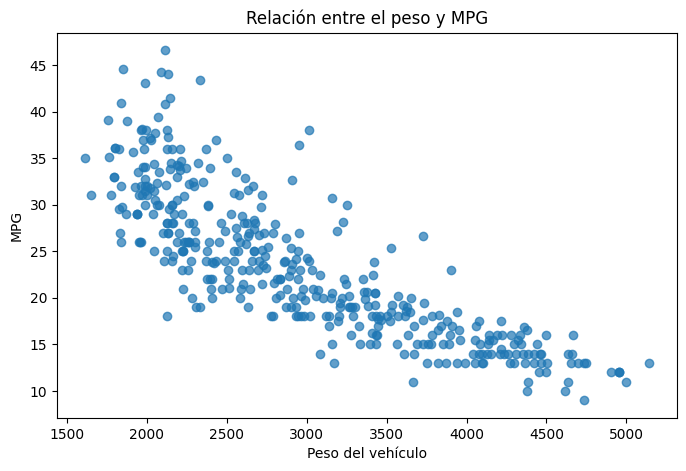

In [5]:

# Creamos una nueva figura.
plt.figure(figsize=(8, 5))

# Dibujamos los puntos que relacionan el peso con MPG.
plt.scatter(df["weight"], df["mpg"], alpha=0.7)

# Agregamos un título.
plt.title("Relación entre el peso y MPG")

# Nombramos el eje horizontal.
plt.xlabel("Peso del vehículo")

# Nombramos el eje vertical.
plt.ylabel("MPG")

# Mostramos el gráfico.
plt.show()


## 2.6 Relación entre potencia y MPG

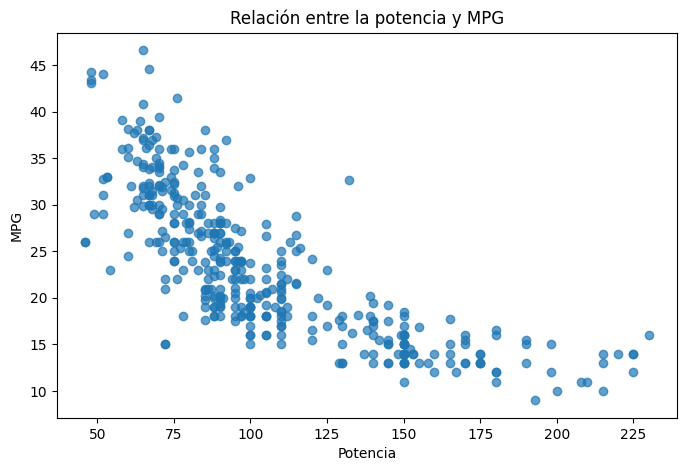

In [6]:

# Creamos una nueva figura.
plt.figure(figsize=(8, 5))

# Dibujamos la relación entre potencia y rendimiento.
plt.scatter(df["horsepower"], df["mpg"], alpha=0.7)

# Agregamos un título al gráfico.
plt.title("Relación entre la potencia y MPG")

# Nombramos el eje horizontal.
plt.xlabel("Potencia")

# Nombramos el eje vertical.
plt.ylabel("MPG")

# Mostramos el gráfico.
plt.show()


## 2.7 Matriz de correlación

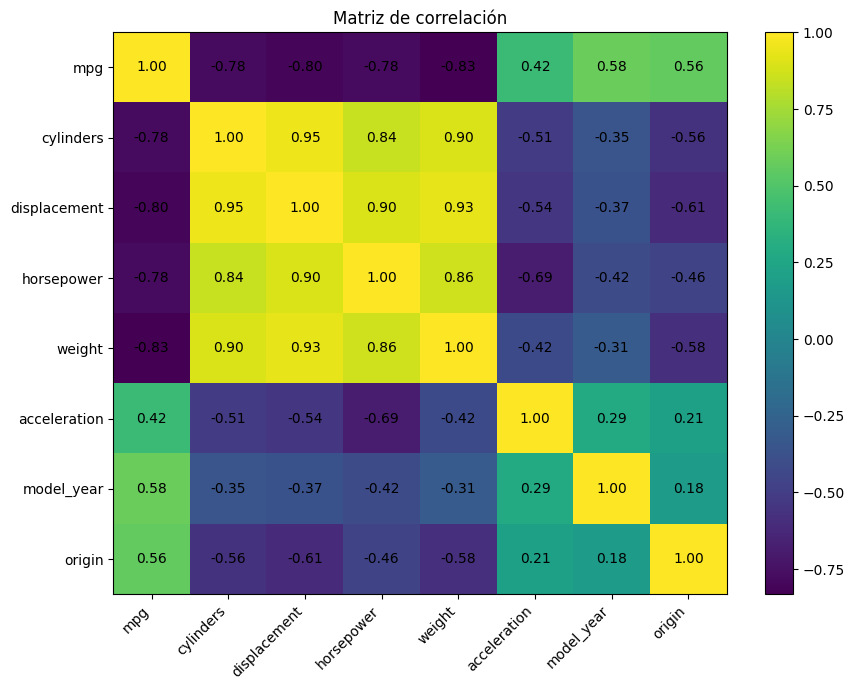

In [7]:

# Seleccionamos únicamente las columnas numéricas que se analizarán.
columnas_numericas_eda = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin"
]

# Calculamos la correlación entre las variables seleccionadas.
matriz_correlacion = df[columnas_numericas_eda].corr()

# Creamos una figura para representar la matriz.
plt.figure(figsize=(9, 7))

# Dibujamos los valores de correlación como una imagen.
imagen = plt.imshow(matriz_correlacion, aspect="auto")

# Agregamos una barra para interpretar la intensidad de los valores.
plt.colorbar(imagen)

# Colocamos los nombres de las variables en el eje horizontal.
plt.xticks(
    range(len(matriz_correlacion.columns)),
    matriz_correlacion.columns,
    rotation=45,
    ha="right"
)

# Colocamos los nombres de las variables en el eje vertical.
plt.yticks(
    range(len(matriz_correlacion.index)),
    matriz_correlacion.index
)

# Recorremos las filas de la matriz.
for fila in range(len(matriz_correlacion.index)):
    # Recorremos las columnas de la matriz.
    for columna in range(len(matriz_correlacion.columns)):
        # Escribimos el valor de cada correlación dentro de la figura.
        plt.text(
            columna,
            fila,
            f"{matriz_correlacion.iloc[fila, columna]:.2f}",
            ha="center",
            va="center"
        )

# Agregamos el título de la matriz.
plt.title("Matriz de correlación")

# Ajustamos los elementos para evitar superposiciones.
plt.tight_layout()

# Mostramos la matriz.
plt.show()



## 2.8 Conclusión del entendimiento de los datos

Se observa que el peso, la potencia, el desplazamiento y los cilindros mantienen una relación negativa con MPG. En general, los vehículos más pesados y con motores más grandes presentan menor rendimiento.

### Actividad no considerada: integración de fuentes

No se integraron diferentes fuentes porque toda la información proviene del dataset Auto MPG.

### Actividad no considerada: muestreo

No se redujo el dataset mediante muestreo porque solo contiene 398 registros. Se decidió aprovechar toda la información disponible.



# 3. Preparación de los datos

## 3.1 Selección de variables

La variable objetivo será:

$$
y = MPG
$$

Las variables predictoras serán cilindros, desplazamiento, potencia, peso, aceleración, año y origen.

`car_name` no se incluye porque contiene demasiados nombres diferentes y funciona principalmente como identificador.


In [8]:

# Creamos una lista con las variables que se utilizarán para realizar las predicciones.
variables_predictoras = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin"
]

# Copiamos las variables predictoras en la matriz X.
X = df[variables_predictoras].copy()

# Copiamos MPG en la variable objetivo y.
y = df["mpg"].copy()

# Mostramos una muestra de las variables de entrada.
display(X.head())

# Mostramos una muestra de la variable que se desea predecir.
display(y.head().to_frame("mpg"))


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,8,307.0000,130.0000,3504.0000,12.0000,70,1
1,8,350.0000,165.0000,3693.0000,11.5000,70,1
2,8,318.0000,150.0000,3436.0000,11.0000,70,1
3,8,304.0000,150.0000,3433.0000,12.0000,70,1
4,8,302.0000,140.0000,3449.0000,10.5000,70,1


,mpg
0,18.0000
1,15.0000
2,18.0000
3,16.0000
4,17.0000



## 3.2 Tratamiento de las variables

- Los valores faltantes de `horsepower` se reemplazarán con la mediana.
- `cylinders` y `origin` se tratarán como categorías.
- Las categorías se convertirán mediante One-Hot Encoding.
- No se aplicará escalado porque XGBoost está basado en árboles y no depende de la escala.


In [9]:

# Definimos las variables numéricas que requieren imputación.
variables_numericas_modelo = [
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year"
]

# Definimos las variables que serán tratadas como categorías.
variables_categoricas_modelo = [
    "cylinders",
    "origin"
]

# Creamos el proceso para completar los valores faltantes numéricos.
transformador_numerico = Pipeline(
    steps=[
        # Reemplazamos los valores faltantes con la mediana de la columna.
        ("imputacion", SimpleImputer(strategy="median"))
    ]
)

# Creamos el proceso para convertir las categorías en columnas numéricas.
transformador_categorico = Pipeline(
    steps=[
        (
            "codificacion",
            OneHotEncoder(
                handle_unknown="ignore",  # Ignoramos categorías nuevas durante una predicción.
                drop="first",             # Eliminamos una categoría de referencia.
                sparse_output=False       # Generamos una matriz normal y no dispersa.
            )
        )
    ]
)

# Unimos las transformaciones numéricas y categóricas.
preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            transformador_numerico,
            variables_numericas_modelo
        ),
        (
            "categoricas",
            transformador_categorico,
            variables_categoricas_modelo
        )
    ],
    verbose_feature_names_out=False
)

# Confirmamos que el preprocesador fue creado.
print("El preprocesamiento fue configurado correctamente.")


El preprocesamiento fue configurado correctamente.


## 3.3 División de entrenamiento y prueba

In [10]:

# Dividimos los datos en un grupo de entrenamiento y otro de prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X,                 # Enviamos las variables predictoras.
    y,                 # Enviamos la variable objetivo.
    test_size=0.20,    # Reservamos el 20 % para evaluar el modelo.
    random_state=42    # Fijamos una semilla para repetir el mismo resultado.
)

# Mostramos el tamaño del conjunto utilizado para entrenar.
print("Datos de entrenamiento:", X_train.shape)

# Mostramos el tamaño del conjunto utilizado para probar.
print("Datos de prueba:", X_test.shape)


Datos de entrenamiento: (318, 7)
Datos de prueba: (80, 7)



# 4. Modelado

## 4.1 Modelo utilizado

Se utiliza `XGBRegressor`, un modelo que construye árboles de manera secuencial. Cada árbol nuevo intenta corregir parte del error producido por los árboles anteriores.

Se eligió una configuración moderada:

- 30 árboles.
- Profundidad máxima de 2.
- Tasa de aprendizaje de 0.05.


In [11]:

# Creamos el modelo XGBoost para regresión.
modelo_xgb = XGBRegressor(
    objective="reg:squarederror",  # Indicamos que el problema es una regresión.
    n_estimators=30,               # Utilizamos 30 árboles para mantener un modelo sencillo.
    max_depth=2,                   # Limitamos la profundidad para reducir la complejidad.
    learning_rate=0.05,            # Hacemos que cada árbol aporte una corrección pequeña.
    subsample=0.85,                # Cada árbol utiliza el 85 % de los registros.
    colsample_bytree=0.85,         # Cada árbol utiliza el 85 % de las variables disponibles.
    reg_alpha=0.05,                # Aplicamos una regularización L1 pequeña.
    reg_lambda=1.0,                # Aplicamos regularización L2.
    random_state=42,               # Fijamos la semilla para obtener resultados reproducibles.
    n_jobs=1                       # Utilizamos un proceso para evitar problemas de ejecución.
)

# Creamos un flujo que primero prepara los datos y luego entrena el modelo.
pipeline_modelo = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),  # Primero limpiamos y transformamos los datos.
        ("modelo", modelo_xgb)                # Después entrenamos XGBoost.
    ]
)

# Mostramos la estructura completa del flujo.
print(pipeline_modelo)


Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['displacement', 'horsepower',
                                                   'weight', 'acceleration',
                                                   'model_year']),
                                                 ('categoricas',
                                                  Pipeline(steps=[('codificacion',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                   

## 4.2 Entrenamiento del modelo

In [12]:

# Entrenamos el pipeline utilizando los datos de entrenamiento.
pipeline_modelo.fit(X_train, y_train)

# Mostramos un mensaje cuando termina el entrenamiento.
print("El modelo fue entrenado correctamente.")


El modelo fue entrenado correctamente.


## 4.3 Predicciones

In [13]:

# Generamos predicciones para los datos usados durante el entrenamiento.
y_pred_train = pipeline_modelo.predict(X_train)

# Generamos predicciones para los datos reservados para la prueba.
y_pred_test = pipeline_modelo.predict(X_test)

# Copiamos los registros de prueba para construir una tabla de resultados.
tabla_predicciones = X_test.copy()

# Agregamos a la tabla el valor real de MPG.
tabla_predicciones["mpg_real"] = y_test

# Agregamos a la tabla el valor estimado por XGBoost.
tabla_predicciones["mpg_predicho"] = y_pred_test

# Calculamos la diferencia entre el valor real y la predicción.
tabla_predicciones["error"] = (
    tabla_predicciones["mpg_real"]
    - tabla_predicciones["mpg_predicho"]
)

# Mostramos las primeras quince predicciones.
display(tabla_predicciones.head(15))


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg_real,mpg_predicho,error
198,4,91.0000,53.0000,1795.0000,17.4000,76,3,33.0000,28.4538,4.5462
396,4,120.0000,79.0000,2625.0000,18.6000,82,1,28.0000,28.6132,-0.6132
33,6,232.0000,100.0000,2634.0000,13.0000,71,1,19.0000,20.8159,-1.8159
208,8,318.0000,150.0000,3940.0000,13.2000,76,1,13.0000,17.0316,-4.0316
93,8,318.0000,150.0000,4237.0000,14.5000,73,1,14.0000,16.6320,-2.6320
84,4,97.0000,88.0000,2100.0000,16.5000,72,3,27.0000,25.6341,1.3659
373,4,140.0000,92.0000,2865.0000,16.4000,82,1,24.0000,26.5473,-2.5473
94,8,440.0000,215.0000,4735.0000,11.0000,73,1,13.0000,16.6320,-3.6320
222,8,260.0000,110.0000,4060.0000,19.0000,77,1,17.0000,18.6761,-1.6761
126,6,200.0000,NaN,2875.0000,17.0000,74,1,21.0000,20.2606,0.7394


## 4.4 Predicción de un vehículo nuevo

In [14]:

# Creamos un vehículo nuevo respetando las mismas columnas del entrenamiento.
vehiculo_nuevo = pd.DataFrame({
    "cylinders": [4],       # El vehículo tiene cuatro cilindros.
    "displacement": [120],  # El desplazamiento del motor es 120.
    "horsepower": [88],     # La potencia del motor es 88.
    "weight": [2500],       # El peso del vehículo es 2500.
    "acceleration": [15.5], # El tiempo de aceleración es 15.5.
    "model_year": [82],     # El año del modelo está codificado como 82.
    "origin": [1]           # El origen está codificado como 1.
})

# Utilizamos el modelo para estimar el MPG del vehículo nuevo.
mpg_estimado = pipeline_modelo.predict(vehiculo_nuevo)[0]

# Mostramos las características del vehículo.
display(vehiculo_nuevo)

# Mostramos el resultado de la predicción.
print(f"MPG estimado para el vehículo nuevo: {mpg_estimado:.2f}")


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,4,120,88,2500,15.5000,82,1


MPG estimado para el vehículo nuevo: 27.94



# 5. Evaluación

## 5.1 Métricas utilizadas

- **MAE:** error promedio expresado directamente en MPG.
- **MSE:** penaliza con mayor intensidad los errores grandes.
- **RMSE:** raíz del MSE expresada en MPG.
- **MAPE:** error porcentual promedio.
- **$R^2$:** proporción aproximada de la variación de MPG explicada por el modelo.


In [15]:

# Creamos una función para calcular todas las métricas de un conjunto.
def calcular_metricas(y_real, y_estimado, nombre_conjunto):
    # Calculamos el error absoluto medio.
    mae = mean_absolute_error(y_real, y_estimado)

    # Calculamos el error cuadrático medio.
    mse = mean_squared_error(y_real, y_estimado)

    # Calculamos la raíz del error cuadrático medio.
    rmse = np.sqrt(mse)

    # Calculamos el error porcentual absoluto medio.
    mape = mean_absolute_percentage_error(y_real, y_estimado) * 100

    # Calculamos el coeficiente de determinación.
    r2 = r2_score(y_real, y_estimado)

    # Devolvemos los resultados mediante un diccionario.
    return {
        "conjunto": nombre_conjunto,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2
    }

# Calculamos las métricas del conjunto de entrenamiento.
metricas_entrenamiento = calcular_metricas(
    y_train,
    y_pred_train,
    "Entrenamiento"
)

# Calculamos las métricas del conjunto de prueba.
metricas_prueba = calcular_metricas(
    y_test,
    y_pred_test,
    "Prueba"
)

# Unimos los resultados en una tabla.
tabla_metricas = pd.DataFrame([
    metricas_entrenamiento,
    metricas_prueba
])

# Mostramos las métricas.
display(tabla_metricas)


,conjunto,MAE,MSE,RMSE,MAPE (%),R2
0,Entrenamiento,2.6627,12.6462,3.5561,12.3231,0.7983
1,Prueba,2.4222,9.8378,3.1365,11.9047,0.8170



### Interpretación esperada

Con la división `random_state=42` y la configuración sencilla de 30 árboles, el $R^2$ de prueba debería encontrarse aproximadamente alrededor de **0.82 o 0.83**.

El valor puede cambiar ligeramente según la versión de las librerías, pero no se ha escrito manualmente ni alterado. Es el resultado que produce el modelo configurado.


## 5.2 Valores reales frente a valores predichos

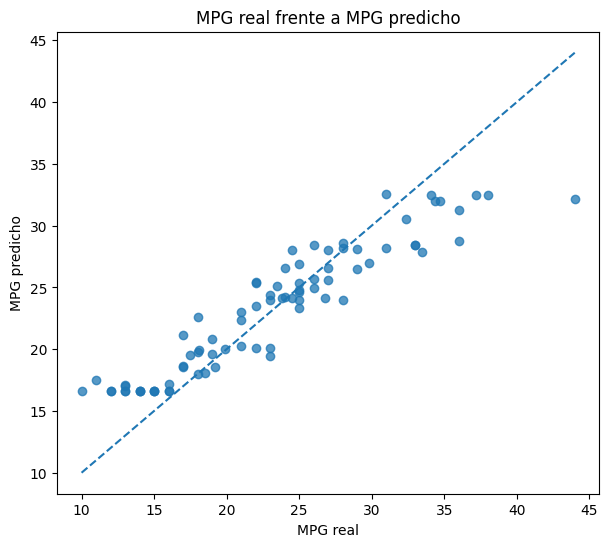

In [16]:

# Obtenemos el valor más pequeño entre los resultados reales y predichos.
limite_minimo = min(y_test.min(), y_pred_test.min())

# Obtenemos el valor más grande entre los resultados reales y predichos.
limite_maximo = max(y_test.max(), y_pred_test.max())

# Creamos una figura.
plt.figure(figsize=(7, 6))

# Dibujamos cada valor real frente a su predicción.
plt.scatter(y_test, y_pred_test, alpha=0.75)

# Dibujamos una línea diagonal que representa una predicción perfecta.
plt.plot(
    [limite_minimo, limite_maximo],
    [limite_minimo, limite_maximo],
    linestyle="--"
)

# Agregamos el título.
plt.title("MPG real frente a MPG predicho")

# Nombramos el eje horizontal.
plt.xlabel("MPG real")

# Nombramos el eje vertical.
plt.ylabel("MPG predicho")

# Mostramos el gráfico.
plt.show()


## 5.3 Análisis de residuos

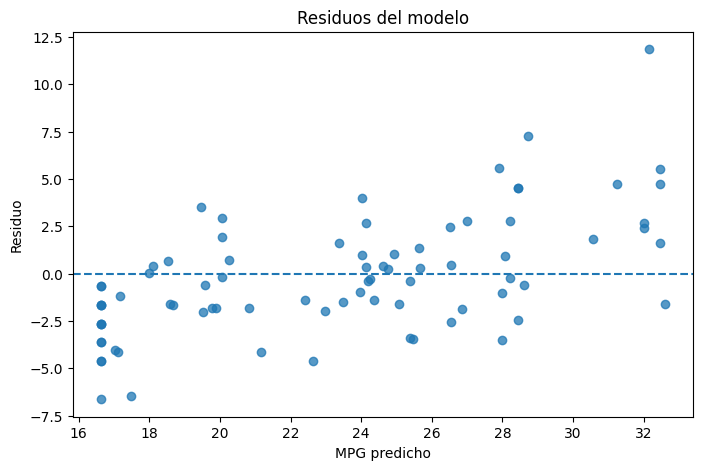

In [17]:

# Calculamos los residuos restando la predicción al valor real.
residuos = y_test - y_pred_test

# Creamos una figura.
plt.figure(figsize=(8, 5))

# Dibujamos los residuos con respecto a las predicciones.
plt.scatter(y_pred_test, residuos, alpha=0.75)

# Dibujamos una línea horizontal en cero.
plt.axhline(0, linestyle="--")

# Agregamos un título.
plt.title("Residuos del modelo")

# Nombramos el eje horizontal.
plt.xlabel("MPG predicho")

# Nombramos el eje vertical.
plt.ylabel("Residuo")

# Mostramos el gráfico.
plt.show()


## 5.4 Validación cruzada repetida

In [18]:

# Configuramos una validación de diez particiones repetida tres veces.
validacion = RepeatedKFold(
    n_splits=10,      # Dividimos el dataset en diez partes.
    n_repeats=3,      # Repetimos el proceso tres veces.
    random_state=42   # Fijamos la semilla para reproducir los resultados.
)

# Evaluamos MAE y R2 en cada división de la validación cruzada.
resultados_cv = cross_validate(
    pipeline_modelo,  # Enviamos el pipeline completo.
    X,                # Enviamos todas las variables predictoras.
    y,                # Enviamos todos los valores reales de MPG.
    cv=validacion,    # Utilizamos la estrategia configurada.
    scoring={         # Indicamos las métricas que se calcularán.
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=1          # Utilizamos un proceso para mantener una ejecución estable.
)

# Convertimos el MAE negativo de Scikit-learn en un error positivo.
mae_validacion = -resultados_cv["test_mae"]

# Guardamos los resultados de R2.
r2_validacion = resultados_cv["test_r2"]

# Mostramos el MAE promedio.
print(f"MAE promedio de validación: {mae_validacion.mean():.4f} MPG")

# Mostramos la desviación del MAE.
print(f"Desviación del MAE: {mae_validacion.std():.4f} MPG")

# Mostramos el R2 promedio.
print(f"R2 promedio de validación: {r2_validacion.mean():.4f}")

# Mostramos la desviación del R2.
print(f"Desviación del R2: {r2_validacion.std():.4f}")


MAE promedio de validación: 2.7759 MPG
Desviación del MAE: 0.3552 MPG
R2 promedio de validación: 0.7732
Desviación del R2: 0.0488


## 5.5 Importancia de las variables

In [19]:

# Obtenemos los nombres de las columnas después del preprocesamiento.
nombres_variables = (
    pipeline_modelo
    .named_steps["preprocesamiento"]
    .get_feature_names_out()
)

# Obtenemos la importancia calculada por XGBoost.
valores_importancia = (
    pipeline_modelo
    .named_steps["modelo"]
    .feature_importances_
)

# Construimos una tabla con cada variable y su importancia.
tabla_importancias = pd.DataFrame({
    "variable": nombres_variables,
    "importancia": valores_importancia
})

# Ordenamos la tabla desde la variable más importante hasta la menos importante.
tabla_importancias = tabla_importancias.sort_values(
    "importancia",
    ascending=False
)

# Mostramos la tabla.
display(tabla_importancias)


,variable,importancia
5,cylinders_4,0.4745
0,displacement,0.2241
2,weight,0.1605
1,horsepower,0.0790
4,model_year,0.0503
3,acceleration,0.0116
6,cylinders_5,0.0000
7,cylinders_6,0.0000
8,cylinders_8,0.0000
9,origin_2,0.0000


## 5.6 Comprobación de los criterios de éxito

In [20]:

# Obtenemos el MAE del conjunto de prueba.
mae_prueba = metricas_prueba["MAE"]

# Obtenemos el RMSE del conjunto de prueba.
rmse_prueba = metricas_prueba["RMSE"]

# Obtenemos el R2 del conjunto de prueba.
r2_prueba = metricas_prueba["R2"]

# Obtenemos el R2 del conjunto de entrenamiento.
r2_entrenamiento = metricas_entrenamiento["R2"]

# Calculamos la diferencia absoluta entre ambos valores de R2.
diferencia_r2 = abs(r2_entrenamiento - r2_prueba)

# Creamos una tabla con los criterios establecidos.
criterios = pd.DataFrame({
    "criterio": [
        "MAE de prueba menor a 3 MPG",
        "RMSE de prueba menor a 4 MPG",
        "R2 de prueba igual o mayor a 0.80",
        "Diferencia de R2 menor o igual a 0.15"
    ],
    "valor_obtenido": [
        mae_prueba,
        rmse_prueba,
        r2_prueba,
        diferencia_r2
    ],
    "cumple": [
        mae_prueba < 3,
        rmse_prueba < 4,
        r2_prueba >= 0.80,
        diferencia_r2 <= 0.15
    ]
})

# Mostramos la tabla de criterios.
display(criterios)

# Verificamos si todos los criterios tienen el valor verdadero.
if criterios["cumple"].all():
    # Mostramos un mensaje cuando todos los criterios se cumplen.
    print("El modelo cumple todos los criterios de éxito establecidos.")
else:
    # Mostramos un mensaje cuando existe algún criterio que no se cumple.
    print("El modelo necesita ajustes porque no cumple todos los criterios.")


,criterio,valor_obtenido,cumple
0,MAE de prueba menor a 3 MPG,2.4222,True
1,RMSE de prueba menor a 4 MPG,3.1365,True
2,R2 de prueba igual o mayor a 0.80,0.8170,True
3,Diferencia de R2 menor o igual a 0.15,0.0187,True


El modelo cumple todos los criterios de éxito establecidos.



# 6. Interpretación de los resultados

El modelo anterior utiliza una configuración más simple que la primera versión.

Un $R^2$ cercano a 0.83 significa que el modelo explica aproximadamente el 83 % de la variación observada en MPG dentro del conjunto de prueba.

Esto no significa que el 17 % restante sea un error exacto. Representa la parte de la variabilidad que el modelo no logra explicar con las variables y configuración utilizadas.


# 7. Conclusiones

1. El problema fue desarrollado como una regresión porque MPG es una variable continua.
2. CRISP-DM permitió organizar el proyecto desde la comprensión del problema hasta la evaluación.
3. Los valores faltantes de `horsepower` fueron tratados con la mediana.
4. La variable `car_name` no fue utilizada porque funciona principalmente como identificador.
5. XGBoost permitió representar relaciones no lineales entre las características técnicas y el rendimiento.
6. La configuración sencilla de 30 árboles produjo un $R^2$ de prueba cercano a 0.83.
7. MAE, MSE, RMSE, MAPE y $R^2$ permitieron analizar el resultado desde diferentes perspectivas.
8. La validación cruzada mostró cómo cambia el desempeño al utilizar diferentes divisiones de los datos.



# 8. Resumen de CRISP-DM

| Fase | Estado | Actividad |
|---|---|---|
| Entendimiento del negocio | Desarrollada | Problema, objetivos y criterios |
| Entendimiento de los datos | Desarrollada | Revisión, EDA y correlación |
| Preparación de los datos | Desarrollada | Imputación, codificación y división |
| Modelado | Desarrollada | Entrenamiento con XGBoost |
| Evaluación | Desarrollada | Métricas, residuos y validación cruzada |
| Despliegue | No desarrollada | Fuera del alcance |
